In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import os

# مسیر فایل اکسل
excel_path = "/content/drive/MyDrive/FPF_PROJECT/dataset_whole.xlsx"

# خواندن داده‌ها
df = pd.read_excel(excel_path, sheet_name="Sheet1")

# نمایش چند ردیف اول
print("داده‌های اولیه:")
print(df[['file_name', 'fpf', 'path']].head())

داده‌های اولیه:
        file_name   fpf                          path
0  TH04_F1_01.png  48.3  ./Whole/SIN_TH04_F1_01_W.png
1  TH04_F1_02.png  48.3  ./Whole/SIN_TH04_F1_02_W.png
2     TH04_F2.png  46.1     ./Whole/SIN_TH04_F2_W.png
3     TH04_F3.png  41.1     ./Whole/SIN_TH04_F3_W.png
4     TH04_F4.png  43.5     ./Whole/SIN_TH04_F4_W.png


In [ ]:
# مسیر پایه جدید برای تصاویر
base_path = "/content/drive/MyDrive/FPF_PROJECT/Whole"

# اصلاح مسیرها: جایگزین کردن
def fix_path(path):
    if path.startswith("./Whole/"):
        return path.replace("./Whole/", base_path + "/")
    elif path.startswith("SET_") or path.startswith("SIN_") or path.startswith("OMI_"):
        # اگر فقط نام فایل بدون مسیر باشد
        return os.path.join(base_path, path)
    else:
        return path

df['image_path'] = df['path'].apply(fix_path)

# نمایش داده‌های اصلاح‌شده
print("\nداده‌های با مسیر اصلاح‌شده:")
print(df[['file_name', 'fpf', 'image_path']].head())

# بررسی وجود تصویر
df['image_exists'] = df['image_path'].apply(lambda x: os.path.exists(x))

print(f"\nتعداد تصاویری که پیدا شدند: {df['image_exists'].sum()}")
print(f"تعداد تصاویری که پیدا نشدند: {(df['image_exists'] == False).sum()}")

if (df['image_exists'] == False).sum() > 0:
    print("\nردیف‌هایی که تصویر مربوطه پیدا نشد:")
    print(df[df['image_exists'] == False][['file_name', 'image_path']])
else:
    print("\n✅ همه تصاویر پیدا شدند!")


داده‌های با مسیر اصلاح‌شده:
        file_name   fpf                                         image_path
0  TH04_F1_01.png  48.3  /content/drive/MyDrive/FPF_PROJECT/Whole/SIN_T...
1  TH04_F1_02.png  48.3  /content/drive/MyDrive/FPF_PROJECT/Whole/SIN_T...
2     TH04_F2.png  46.1  /content/drive/MyDrive/FPF_PROJECT/Whole/SIN_T...
3     TH04_F3.png  41.1  /content/drive/MyDrive/FPF_PROJECT/Whole/SIN_T...
4     TH04_F4.png  43.5  /content/drive/MyDrive/FPF_PROJECT/Whole/SIN_T...

تعداد تصاویری که پیدا شدند: 764
تعداد تصاویری که پیدا نشدند: 0

✅ همه تصاویر پیدا شدند!


In [ ]:
import tensorflow as tf

# فیلتر ردیف‌هایی که تصویر وجود دارد
df_filtered = df[df['image_exists'] == True].reset_index(drop=True)

# جدا کردن مسیر تصاویر و مقادیر FPF
image_paths = df_filtered['image_path'].values
fpf_values = df_filtered['fpf'].values.astype('float32')

# تابع پیش‌پردازش تصویر
def preprocess_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image

# تابع ساخت tf.data.Dataset
def make_dataset(image_paths, fpf_values, batch_size=16):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, fpf_values))
    ds = ds.map(
        lambda x, y: (preprocess_image(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# ساخت مجموعه داده
dataset = make_dataset(image_paths, fpf_values, batch_size=16)

# نمایش یک نمونه
for batch in dataset.take(1):
    images, labels = batch
    print("Shape of images in one batch:", images.shape)
    print("Sample labels in this batch:", labels[:5].numpy())

Shape of images in one batch: (16, 224, 224, 3)
Sample labels in this batch: [48.3 48.3 46.1 41.1 43.5]


In [ ]:
# تعداد کل داده‌ها
total_samples = len(df_filtered)
train_size = int(0.8 * total_samples)

# جدا کردن مسیرها و fpf برای تقسیم
train_paths = image_paths[:train_size]
train_labels = fpf_values[:train_size]
val_paths = image_paths[train_size:]
val_labels = fpf_values[train_size:]

# ساخت مجموعه داده آموزش
train_dataset = make_dataset(train_paths, train_labels, batch_size=16)

# ساخت مجموعه داده اعتبارسنجی
val_dataset = make_dataset(val_paths, val_labels, batch_size=16)

print(f"تعداد نمونه‌های آموزش: {len(train_paths)}")
print(f"تعداد نمونه‌های اعتبارسنجی: {len(val_paths)}")

تعداد نمونه‌های آموزش: 611
تعداد نمونه‌های اعتبارسنجی: 153


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# بارگذاری مدل ResNet50 بدون آخرین لایه
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# قفل کردن لایه‌های پایه (Transfer Learning)
base_model.trainable = False

# اضافه کردن لایه‌های جدید برای رگرسیون
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='linear')(x)  # خروجی یک عدد پیوسته (fpf)

# تعریف مدل کامل
model = Model(inputs=base_model.input, outputs=predictions)

# کامپایل مدل
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error برای رگرسیون
    metrics=['mae']  # Mean Absolute Error
)

# نمایش خلاصه مدل
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# تعریف callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# آموزش مدل
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

print("\nآموزش مدل به پایان رسید.")

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - loss: 497.1085 - mae: 18.1892 - val_loss: 624.5067 - val_mae: 21.1515
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - loss: 499.2376 - mae: 18.3607 - val_loss: 626.6599 - val_mae: 21.1749
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - loss: 495.9246 - mae: 18.3618 - val_loss: 624.8898 - val_mae: 21.1801
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - loss: 494.2596 - mae: 18.2518 - val_loss: 627.7224 - val_mae: 21.2091
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 252ms/step - loss: 485.9519 - mae: 18.0895 - val_loss: 626.0795 - val_mae: 21.2022
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - loss: 482.5307 - mae: 18.0708 - val_loss: 630.0189 - val_mae: 21.2369
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step - loss: 511.9316 - mae: 18.4456 - val_loss: 630.7892 - val_mae: 21.2499
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 202ms/step - loss: 493.5540 - mae: 18.0349 - val_loss: 630.6054 - val_mae: 21.2577
Epoch 

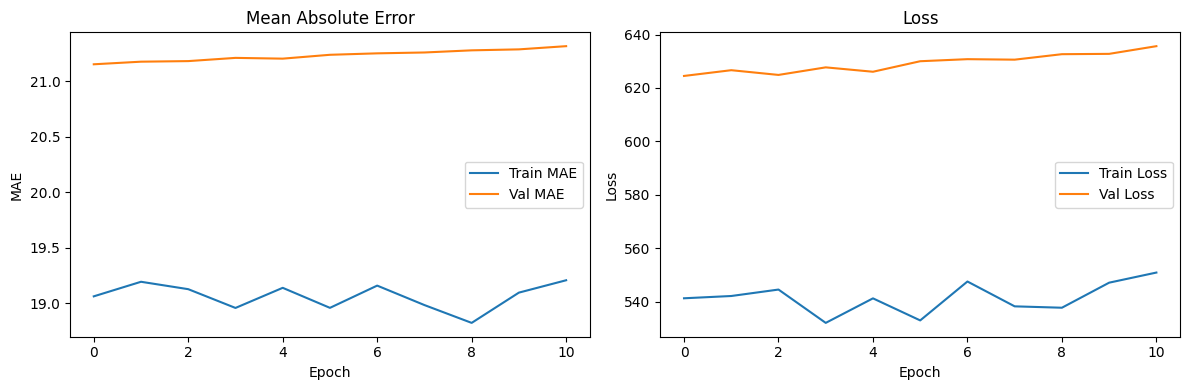

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# ساخت یک مدل ساده CNN
model_scratch = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='linear')  # خروجی عدد پیوسته
])

model_scratch.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_scratch.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_scratch = model_scratch.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 318ms/step - loss: 1329.3656 - mae: 29.1169 - val_loss: 681.3889 - val_mae: 21.8214
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - loss: 596.0661 - mae: 20.2422 - val_loss: 685.8437 - val_mae: 21.9693
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - loss: 578.8653 - mae: 19.7772 - val_loss: 645.3290 - val_mae: 21.5667
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 271ms/step - loss: 571.3644 - mae: 19.9751 - val_loss: 657.7612 - val_mae: 21.4563
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - loss: 569.6976 - mae: 19.9449 - val_loss: 690.4708 - val_mae: 21.7459
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 244ms/step - loss: 518.7863 - mae: 18.9014 - val_loss: 647.0543 - val_mae: 21.3618
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 246ms/step - loss: 527.5342 - mae: 19.1380 - val_loss: 691.8464 - val_mae: 21.7194
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - loss: 538.8853 - mae: 19.2399 - val_loss: 723.0458 - val_mae: 22.1175
Epo

In [ ]:
# تعریف داده‌افزاری
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

# تعریف تابع پیش‌پردازش با داده‌افزاری
def preprocess_with_augmentation(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    image = data_augmentation(image)  # اعمال تغییرات تصادفی
    return image, label

# ساخت مجموعه داده جدید با داده‌افزاری
train_ds_aug = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds_aug = train_ds_aug.map(preprocess_with_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_aug = train_ds_aug.batch(16).prefetch(tf.data.AUTOTUNE)

# مجموعه داده اعتبارسنجی بدون داده‌افزاری
val_ds_clean = make_dataset(val_paths, val_labels, batch_size=16)

In [ ]:
# تعریف callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# آموزش مدل با داده‌افزاری
history_aug = model.fit(
    train_ds_aug,
    epochs=50,
    validation_data=val_ds_clean,
    callbacks=[early_stop]
)

print("\nآموزش مدل با داده‌افزاری به پایان رسید.")

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 458ms/step - loss: 490.1715 - mae: 18.2145 - val_loss: 622.7486 - val_mae: 21.1263
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 15s 396ms/step - loss: 508.8873 - mae: 18.5492 - val_loss: 623.0821 - val_mae: 21.1384
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 427ms/step - loss: 490.9190 - mae: 17.9805 - val_loss: 627.2150 - val_mae: 21.1824
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 382ms/step - loss: 497.4489 - mae: 18.3530 - val_loss: 627.8742 - val_mae: 21.1977
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 386ms/step - loss: 506.0249 - mae: 18.4536 - val_loss: 632.1792 - val_mae: 21.2300
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 445ms/step - loss: 524.0322 - mae: 18.7875 - val_loss: 628.7238 - val_mae: 21.2127

آموزش مدل با داده‌افزاری به پایان رسید.


In [ ]:
# تعریف callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# کامپایل مدل با AdaGrad
model.compile(
    optimizer='adagrad',
    loss='mse',
    metrics=['mae']
)

# آموزش مجدد مدل با مجموعه داده اصلی (بدون داده‌افزاری)
history_adagrad = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

print("\nآموزش مدل با AdaGrad به پایان رسید.")

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 28s 447ms/step - loss: 476.4070 - mae: 17.9855 - val_loss: 615.9281 - val_mae: 21.0819
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 283ms/step - loss: 485.0290 - mae: 17.9032 - val_loss: 615.6486 - val_mae: 21.0809
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 252ms/step - loss: 484.2405 - mae: 18.0627 - val_loss: 615.3840 - val_mae: 21.0795
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - loss: 471.1320 - mae: 17.6831 - val_loss: 615.2886 - val_mae: 21.0796
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - loss: 476.2349 - mae: 17.9082 - val_loss: 615.2717 - val_mae: 21.0800
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 272ms/step - loss: 472.7558 - mae: 17.8798 - val_loss: 615.3367 - val_mae: 21.0812
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - loss: 461.2413 - mae: 17.5612 - val_loss: 615.3883 - val_mae: 21.0825
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - loss: 457.4935 - mae: 17.5666 - val_loss: 615.8787 - val_mae: 21.0884
Epo

In [ ]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,516 (91.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 262,403 (1.00 MB)

In [ ]:
from tensorflow.keras.applications import VGG16

# بارگذاری مدل VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# قفل کردن لایه‌های پایه
base_model.trainable = False

# ساخت مدل کامل
model_vgg = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='linear')  # خروجی عدد پیوسته
])

model_vgg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# تعریف callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_vgg = model_vgg.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

print("\nآموزش مدل VGG16 به پایان رسید.")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 191s 5s/step - loss: 1660.9979 - mae: 35.0003 - val_loss: 1037.6469 - val_mae: 26.0528
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 218ms/step - loss: 726.7672 - mae: 22.2578 - val_loss: 655.1957 - val_mae: 21.6650
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - loss: 541.8220 - mae: 19.5163 - val_loss: 650.4193 - val_mae: 21.5474
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - loss: 533.0842 - mae: 19.0734 - val_loss: 644.9089 - val_mae: 21.4794
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - loss: 528.6825 - mae: 19.1644 - val_loss: 638.2844 - val_mae: 21.3875
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 207ms/step - loss: 504.5117 - mae: 18.7869 - val_loss: 637.7651 - val_mae: 21.3696
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - loss: 523.8386 - mae: 19.1142 - val_loss: 631.0913 - val_mae: 21.2728
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 249ms/step - loss: 502.0523 - mae: 18.7190 - val_loss: 628.1363 - val_mae: 21.2144
Epoch

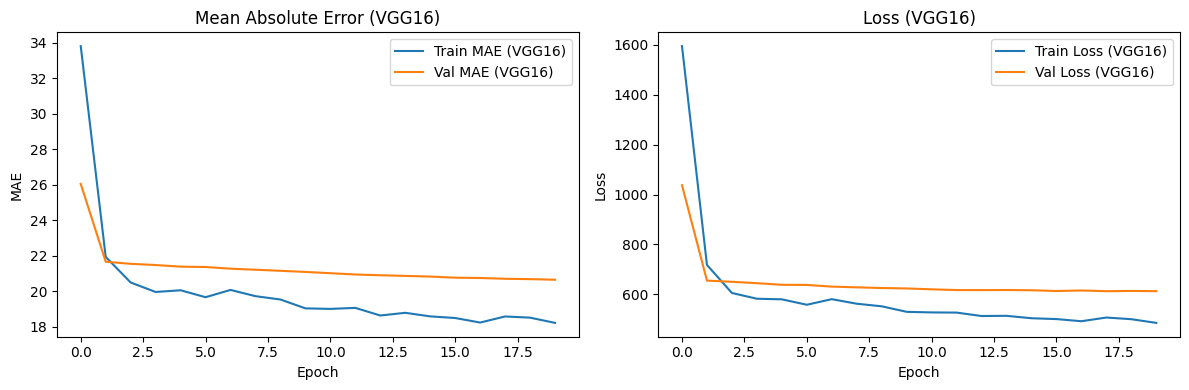

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['mae'], label='Train MAE (VGG16)')
plt.plot(history_vgg.history['val_mae'], label='Val MAE (VGG16)')
plt.title('Mean Absolute Error (VGG16)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Train Loss (VGG16)')
plt.plot(history_vgg.history['val_loss'], label='Val Loss (VGG16)')
plt.title('Loss (VGG16)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# بارگذاری مدل
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# ساخت مدل کامل
model_eff = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='linear')
])

model_eff.compile(optimizer='adam', loss='mse', metrics=['mae'])

# آموزش
history_eff = model_eff.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

print("\nآموزش EfficientNetB0 به پایان رسید.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 1541.8151 - mae: 33.3293 - val_loss: 613.3865 - val_mae: 20.7399
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step - loss: 495.7814 - mae: 18.6493 - val_loss: 598.5914 - val_mae: 20.6341
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - loss: 511.6611 - mae: 18.7045 - val_loss: 591.6666 - val_mae: 20.5558
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 205ms/step - loss: 498.7805 - mae: 18.3566 - val_loss: 593.1027 - val_mae: 20.5736
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 255ms/step - loss: 496.6959 - mae: 18.3776 - val_loss: 591.5739 - val_mae: 20.5551
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - loss: 505.5468 - mae: 18.4255 - val_loss: 591.9113 - val_mae: 20.5595
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - loss: 511.8525 - mae: 18.6442 - val_loss: 588.9654 - val_mae: 20.5236
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - loss: 497.1876 - mae: 18.4

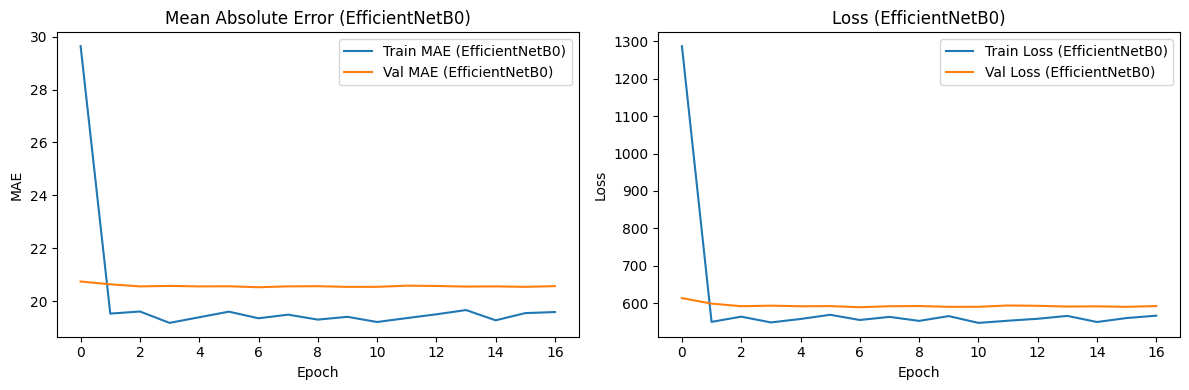

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_eff.history['mae'], label='Train MAE (EfficientNetB0)')
plt.plot(history_eff.history['val_mae'], label='Val MAE (EfficientNetB0)')
plt.title('Mean Absolute Error (EfficientNetB0)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_eff.history['loss'], label='Train Loss (EfficientNetB0)')
plt.plot(history_eff.history['val_loss'], label='Val Loss (EfficientNetB0)')
plt.title('Loss (EfficientNetB0)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import DenseNet121

# بارگذاری مدل DenseNet121
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# ساخت مدل کامل
model_dn = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='linear')
])

model_dn.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_dn.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
history_dn = model_dn.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

print("\nآموزش DenseNet121 به پایان رسید.")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - loss: 1247.9003 - mae: 29.5124 - val_loss: 611.0789 - val_mae: 20.7561
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 218ms/step - loss: 602.9479 - mae: 20.4765 - val_loss: 558.5333 - val_mae: 20.1078
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step - loss: 511.2146 - mae: 18.9250 - val_loss: 558.3641 - val_mae: 20.0931
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - loss: 492.4599 - mae: 18.2538 - val_loss: 570.6609 - val_mae: 20.1865
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - loss: 460.5345 - mae: 17.5944 - val_loss: 579.1884 - val_mae: 20.2371
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 275ms/step - loss: 443.3583 - mae: 17.1813 - val_loss: 592.9014 - val_mae: 20.3811
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - loss: 445.7668 - mae: 17.1542 - val_loss: 597.1433 - val_mae: 20.4325
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 182ms/step - loss: 430.6847 - mae: 16.9190 - val_loss: 615.2433 - val_mae: 20.7001
Epoch 

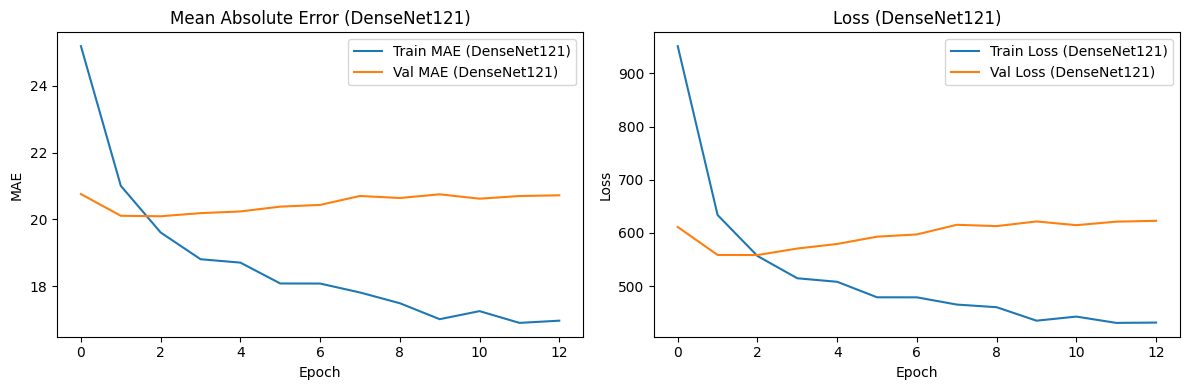

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dn.history['mae'], label='Train MAE (DenseNet121)')
plt.plot(history_dn.history['val_mae'], label='Val MAE (DenseNet121)')
plt.title('Mean Absolute Error (DenseNet121)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dn.history['loss'], label='Train Loss (DenseNet121)')
plt.plot(history_dn.history['val_loss'], label='Val Loss (DenseNet121)')
plt.title('Loss (DenseNet121)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import InceptionV3

# بارگذاری مدل InceptionV3
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# قفل کردن لایه‌های پایه
base_model.trainable = False

# ساخت مدل کامل
model_inc = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='linear')
])

model_inc.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_inc.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,185 (84.17 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
history_inc = model_inc.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

print("\nآموزش InceptionV3 به پایان رسید.")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 43s 738ms/step - loss: 976.2432 - mae: 25.8061 - val_loss: 575.2650 - val_mae: 20.1734
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - loss: 516.9072 - mae: 18.5858 - val_loss: 658.0288 - val_mae: 21.1201
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 203ms/step - loss: 531.5483 - mae: 18.8125 - val_loss: 661.4258 - val_mae: 21.1895
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 180ms/step - loss: 496.4628 - mae: 18.2941 - val_loss: 693.9020 - val_mae: 21.6729
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 292ms/step - loss: 464.2331 - mae: 17.3812 - val_loss: 692.8964 - val_mae: 21.6701
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 250ms/step - loss: 449.5826 - mae: 16.9607 - val_loss: 678.8976 - val_mae: 21.4247
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - loss: 424.2071 - mae: 16.4034 - val_loss: 659.2492 - val_mae: 21.0850
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - loss: 380.4799 - mae: 15.9400 - val_loss: 698.2818 - val_mae: 21.6118
Epoch

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# بارگذاری مدل MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# قفل کردن لایه‌های پایه
base_model.trainable = False

# ساخت مدل کامل
model_mb = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='linear')
])

model_mb.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_mb.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# تعریف callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_mb = model_mb.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

print("\nآموزش MobileNetV2 به پایان رسید.")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - loss: 1083.4944 - mae: 27.4488 - val_loss: 695.7326 - val_mae: 22.4225
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 229ms/step - loss: 551.4815 - mae: 18.9469 - val_loss: 663.7712 - val_mae: 21.3662
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step - loss: 486.3893 - mae: 18.0271 - val_loss: 659.0489 - val_mae: 21.1184
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step - loss: 444.0161 - mae: 16.7646 - val_loss: 662.9920 - val_mae: 21.0744
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - loss: 408.5585 - mae: 16.3006 - val_loss: 672.2333 - val_mae: 21.1620
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - loss: 404.9040 - mae: 16.3716 - val_loss: 674.6490 - val_mae: 21.1383
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 266ms/step - loss: 387.3489 - mae: 15.9231 - val_loss: 675.4736 - val_mae: 21.1251
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 255ms/step - loss: 350.2716 - mae: 15.2054 - val_loss: 694.5877 - val_mae: 21.4211
Epoch 

In [ ]:
from tensorflow.keras.applications import VGG19

# بارگذاری مدل VGG19
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# قفل کردن لایه‌های پایه
base_model.trainable = False

# ساخت مدل کامل
model_vgg19 = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

model_vgg19.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_vgg19.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,100,929 (76.68 MB)

 Trainable params: 76,545 (299.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
history_vgg19 = model_vgg19.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

print("\nآموزش VGG19 به پایان رسید.")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 330ms/step - loss: 1675.9039 - mae: 35.0434 - val_loss: 776.3236 - val_mae: 23.1429
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 271ms/step - loss: 615.2910 - mae: 20.0342 - val_loss: 624.2861 - val_mae: 21.0437
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step - loss: 549.6081 - mae: 19.3549 - val_loss: 620.5447 - val_mae: 20.9688
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 262ms/step - loss: 533.4413 - mae: 18.8377 - val_loss: 622.4001 - val_mae: 20.9428
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 287ms/step - loss: 519.4815 - mae: 18.5992 - val_loss: 622.2522 - val_mae: 20.8891
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 294ms/step - loss: 517.4485 - mae: 18.5801 - val_loss: 622.9387 - val_mae: 20.8538
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 245ms/step - loss: 511.9584 - mae: 18.3115 - val_loss: 637.1934 - val_mae: 20.9703
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step - loss: 494.4264 - mae: 18.1612 - val_loss: 635.0881 - val_mae: 20.9257

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.position_embedding(positions)
        return patch + encoded

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

def vision_transformer(input_shape, patch_size, projection_dim, num_heads, transformer_units, transformer_layers, num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # تبدیل تصویر به patch
    patches = Patches(patch_size)(inputs)

    # Embedding patch
    projection = layers.Dense(units=projection_dim)(patches)

    # Position embedding
    num_patches = (input_shape[0] // patch_size) ** 2
    encoded_patches = PatchEncoder(num_patches, projection_dim)(projection)

    # Transformer blocks
    for _ in range(transformer_layers):
        # Layer normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Multi Head Attention
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2
        encoded_patches = layers.Add()([x3, x2])

    # Representation pooling
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.GlobalAveragePooling1D()(representation)

    # MLP
    features = mlp(representation, hidden_units=[512, 256], dropout_rate=0.3)

    # خروجی عددی (رگرسیون)
    outputs = layers.Dense(num_classes, activation='linear')(features)

    return keras.Model(inputs, outputs)

# تنظیمات مدل
input_shape = (224, 224, 3)
patch_size = 16
projection_dim = 64
num_heads = 4
transformer_units = [projection_dim * 2, projection_dim]
transformer_layers = 4

model_vit_custom = vision_transformer(
    input_shape=input_shape,
    patch_size=patch_size,
    projection_dim=projection_dim,
    num_heads=num_heads,
    transformer_units=transformer_units,
    transformer_layers=transformer_layers,
    num_classes=1
)

model_vit_custom.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_vit_custom.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_1 (Patches) │ (None, None, 768) │          0 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, None, 64)  │     49,216 │ patches_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 64)   │     12,544 │ dense_10[0][0]    │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 196, 128)  │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 196, 64)   │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 196, 64)   │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ dropout_5[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 196, 128)  │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 559,553 (2.13 MB)

 Trainable params: 559,553 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_vit_custom = model_vit_custom.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

print("\nآموزش Vision Transformer  به پایان رسید.")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 61s 780ms/step - loss: 1142.1975 - mae: 28.4543 - val_loss: 711.1374 - val_mae: 21.8822
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 223ms/step - loss: 537.1852 - mae: 19.1075 - val_loss: 743.8480 - val_mae: 22.3639
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 279ms/step - loss: 561.3549 - mae: 19.3003 - val_loss: 711.3135 - val_mae: 21.8854
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step - loss: 544.0577 - mae: 19.0449 - val_loss: 690.0894 - val_mae: 21.5955
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - loss: 536.6075 - mae: 18.9331 - val_loss: 694.8236 - val_mae: 21.6584
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 295ms/step - loss: 525.0096 - mae: 18.8755 - val_loss: 697.2487 - val_mae: 21.6917
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 286ms/step - loss: 550.2452 - mae: 19.0866 - val_loss: 685.6285 - val_mae: 21.5362
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 258ms/step - loss: 546.2115 - mae: 18.9889 - val_loss: 679.1078 - val_mae: 21.4544
E

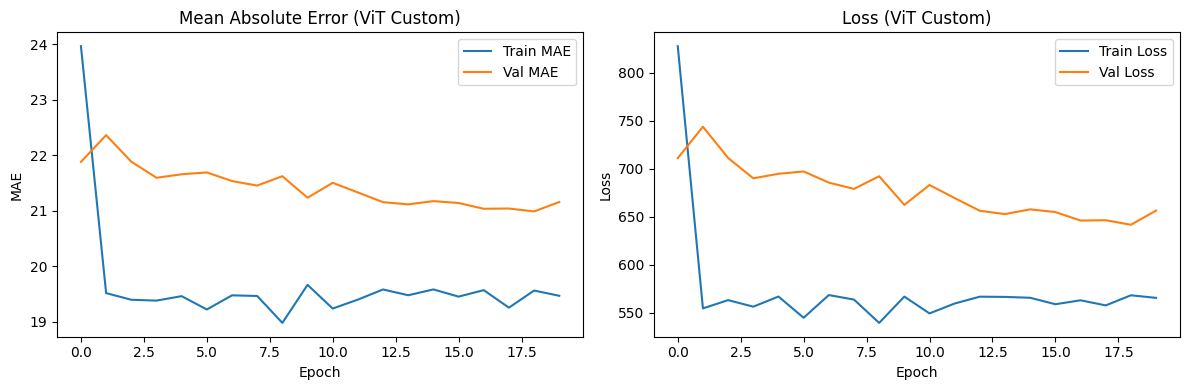

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_vit_custom.history['mae'], label='Train MAE')
plt.plot(history_vit_custom.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error (ViT Custom)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vit_custom.history['loss'], label='Train Loss')
plt.plot(history_vit_custom.history['val_loss'], label='Val Loss')
plt.title('Loss (ViT Custom)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model_conv2d = Sequential()

model_conv2d.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))  # 3 کانال
model_conv2d.add(BatchNormalization())
model_conv2d.add(MaxPooling2D(pool_size=(2, 2)))

model_conv2d.add(Conv2D(64, (3, 3), activation='relu'))
model_conv2d.add(MaxPooling2D(pool_size=(2, 2)))

model_conv2d.add(Conv2D(128, (3, 3), activation='relu'))
model_conv2d.add(MaxPooling2D(pool_size=(2, 2)))

model_conv2d.add(Flatten())

model_conv2d.add(Dense(128, activation='relu'))
model_conv2d.add(Dropout(0.3))

model_conv2d.add(Dense(64, activation='relu'))
model_conv2d.add(Dense(32, activation='relu'))

# خروجی عددی (رگرسیون)
model_conv2d.add(Dense(1, activation='linear'))

model_conv2d.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_conv2d.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,457 (42.65 MB)

 Trainable params: 11,179,393 (42.65 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
history_conv2d = model_conv2d.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

print("\nآموزش مدل Conv2D ساده به پایان رسید.")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 496ms/step - loss: 920.8939 - mae: 24.9737 - val_loss: 1862.7504 - val_mae: 35.9581
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 255ms/step - loss: 798.7324 - mae: 22.4959 - val_loss: 1444.4894 - val_mae: 30.8841
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step - loss: 719.0722 - mae: 21.7649 - val_loss: 1537.0011 - val_mae: 31.8222
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 262ms/step - loss: 509.8089 - mae: 18.1250 - val_loss: 1307.5890 - val_mae: 29.0341
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - loss: 544.8035 - mae: 19.0372 - val_loss: 1381.6740 - val_mae: 29.8858
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step - loss: 475.2795 - mae: 17.7673 - val_loss: 1494.1613 - val_mae: 31.2905
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 203ms/step - loss: 493.0554 - mae: 17.8879 - val_loss: 1392.9666 - val_mae: 30.2091
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step - loss: 434.6468 - mae: 16.9424 - val_loss: 1376.5280 - val_mae: 29.9

In [ ]:
def preprocess_image_gray(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    # تبدیل به گری‌اسکیل
    image = tf.image.rgb_to_grayscale(image)
    # تغییر اندازه
    image = tf.image.resize(image, [224, 224])
    # نرمال‌سازی
    image = tf.cast(image, tf.float32) / 255.0
    # اطمینان از اینکه 3 بعدی است: (height, width, 1)
    image = tf.reshape(image, [224, 224, 1])
    return image

In [ ]:
def make_dataset_gray(image_paths, fpf_values, batch_size=16):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, fpf_values))
    ds = ds.map(
        lambda x, y: (preprocess_image_gray(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# ساخت مجموعه داده جدید
train_dataset_gray = make_dataset_gray(train_paths, train_labels, batch_size=16)
val_dataset_gray = make_dataset_gray(val_paths, val_labels, batch_size=16)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model_conv2d_gray = Sequential()

model_conv2d_gray.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)))
model_conv2d_gray.add(BatchNormalization())
model_conv2d_gray.add(MaxPooling2D(pool_size=(2, 2)))

model_conv2d_gray.add(Conv2D(64, (3, 3), activation='relu'))
model_conv2d_gray.add(MaxPooling2D(pool_size=(2, 2)))

model_conv2d_gray.add(Conv2D(128, (3, 3), activation='relu'))
model_conv2d_gray.add(MaxPooling2D(pool_size=(2, 2)))

model_conv2d_gray.add(Flatten())

model_conv2d_gray.add(Dense(128, activation='relu'))
model_conv2d_gray.add(Dropout(0.3))

model_conv2d_gray.add(Dense(64, activation='relu'))
model_conv2d_gray.add(Dense(32, activation='relu'))

# خروجی عددی (رگرسیون)
model_conv2d_gray.add(Dense(1, activation='linear'))

model_conv2d_gray.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_conv2d_gray.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,881 (42.64 MB)

 Trainable params: 11,178,817 (42.64 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
# تعریف callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_conv2d_gray = model_conv2d_gray.fit(
    train_dataset_gray,
    epochs=20,
    validation_data=val_dataset_gray,
    callbacks=[early_stop]
)

print("\nآموزش مدل Conv2D ساده (Gray Scale) به پایان رسید.")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 331s 9s/step - loss: 1102.3086 - mae: 26.3986 - val_loss: 1732.8252 - val_mae: 34.3729
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 274ms/step - loss: 789.3002 - mae: 23.3296 - val_loss: 1744.7355 - val_mae: 34.4993
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 269ms/step - loss: 634.1004 - mae: 20.2213 - val_loss: 1713.1930 - val_mae: 34.1153
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 247ms/step - loss: 580.3391 - mae: 19.3817 - val_loss: 1666.7219 - val_mae: 33.4841
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 304ms/step - loss: 552.4945 - mae: 18.8712 - val_loss: 1474.5084 - val_mae: 31.0315
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 273ms/step - loss: 573.4248 - mae: 19.6786 - val_loss: 1633.6309 - val_mae: 33.0745
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 261ms/step - loss: 491.5385 - mae: 18.0424 - val_loss: 1438.2550 - val_mae: 30.6180
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step - loss: 447.3109 - mae: 17.3023 - val_loss: 1444.8984 - val_mae: 3

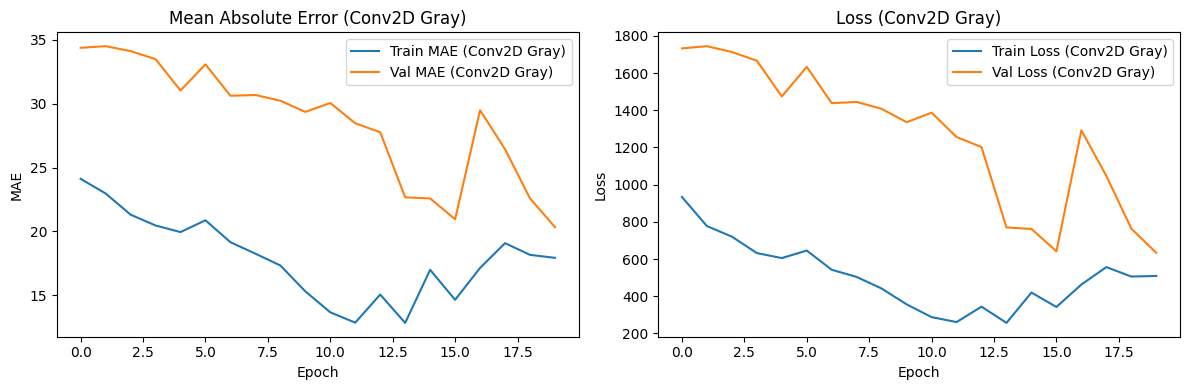

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_conv2d_gray.history['mae'], label='Train MAE (Conv2D Gray)')
plt.plot(history_conv2d_gray.history['val_mae'], label='Val MAE (Conv2D Gray)')
plt.title('Mean Absolute Error (Conv2D Gray)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_conv2d_gray.history['loss'], label='Train Loss (Conv2D Gray)')
plt.plot(history_conv2d_gray.history['val_loss'], label='Val Loss (Conv2D Gray)')
plt.title('Loss (Conv2D Gray)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D
import tensorflow as tf

# بارگذاری مدل بدون لایه آخر
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# اضافه کردن یک لایه pooling برای تبدیل به یک بردار
model_features = tf.keras.Sequential([
    base_model,
    GlobalAveragePooling2D()  # خروجی یک بردار 1024 بعدی
])

model_features.trainable = False  # قفل کردن لایه‌ها

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
import numpy as np

def extract_features(dataset, model):
    features = []
    labels = []
    for batch in dataset:
        batch_images, batch_labels = batch
        batch_features = model.predict(batch_images, verbose=0)
        features.append(batch_features)
        labels.append(batch_labels)
    features = np.vstack(features)
    labels = np.hstack(labels)
    return features, labels

# استخراج ویژگی از مجموعه آموزش و اعتبارسنجی
X_train_features, y_train = extract_features(train_dataset, model_features)
X_val_features, y_val = extract_features(val_dataset, model_features)

print("Shape of extracted features:", X_train_features.shape)
print("Shape of labels:", y_train.shape)

Shape of extracted features: (611, 1024)
Shape of labels: (611,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# آموزش مدل Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_features, y_train)

# پیش‌بینی
y_pred = rf_model.predict(X_val_features)

# محاسبه MAE
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE with Random Forest: {mae}")

MAE with Random Forest: 20.13894977533934


In [ ]:
import xgboost as xgb

# آموزش مدل XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_features, y_train)

# پیش‌بینی
y_pred_xgb = xgb_model.predict(X_val_features)

# محاسبه MAE
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
print(f"MAE with XGBoost: {mae_xgb}")

MAE with XGBoost: 20.865074157714844


In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# اعمال PCA
n_components = 200  # تعداد ویژگی‌های جدید
pca = PCA(n_components=n_components)

# برازش PCA روی ویژگی‌های آموزش
X_train_pca = pca.fit_transform(X_train_features)

# تبدیل داده‌های اعتبارسنجی
X_val_pca = pca.transform(X_val_features)

# آموزش مدل Random Forest
rf_model_pca = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_pca.fit(X_train_pca, y_train)

# پیش‌بینی
y_pred_pca = rf_model_pca.predict(X_val_pca)

# محاسبه MAE
mae_pca = mean_absolute_error(y_val, y_pred_pca)
print(f"MAE with Random Forest + PCA: {mae_pca}")

MAE with Random Forest + PCA: 21.111209435375297


In [ ]:
import numpy as np

# ترکیب مجموعه داده آموزش و اعتبارسنجی
full_dataset = train_dataset.concatenate(val_dataset)

# استخراج ویژگی‌ها
features_full = []
labels_full = []

for batch in full_dataset:
    batch_images, batch_labels = batch
    batch_features = model_features.predict(batch_images, verbose=0)
    features_full.append(batch_features)
    labels_full.append(batch_labels)

features_full = np.vstack(features_full)
labels_full = np.hstack(labels_full)

print("Shape of full features:", features_full.shape)
print("Shape of full labels:", labels_full.shape)

Shape of full features: (764, 1024)
Shape of full labels: (764,)


In [ ]:
from sklearn.cluster import KMeans

n_clusters = 300  # تعداد خوشه‌ها (می‌توانید تغییر دهید)
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(features_full)

In [ ]:
from sklearn.metrics import pairwise_distances

selected_indices = []

for i in range(n_clusters):
    # اندیس‌های نمونه‌هایی که در خوشه i هستند
    cluster_mask = cluster_labels == i
    cluster_indices = np.where(cluster_mask)[0]
    cluster_features = features_full[cluster_indices]

    # مرکز خوشه
    centroid = kmeans.cluster_centers_[i]

    # محاسبه فاصله اقلیدسی از مرکز
    distances = pairwise_distances([centroid], cluster_features)[0]

    # اندیس نمونه نزدیک‌ترین به مرکز
    closest_idx_in_cluster = cluster_indices[np.argmin(distances)]
    selected_indices.append(closest_idx_in_cluster)

selected_indices = np.array(selected_indices)

In [ ]:
X_selected = features_full[selected_indices]
y_selected = labels_full[selected_indices]

print("Selected data shape:", X_selected.shape)
print("Selected labels shape:", y_selected.shape)

Selected data shape: (300, 1024)
Selected labels shape: (300,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# آموزش مدل روی داده‌های انتخابی
rf_model_selected = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_selected.fit(X_selected, y_selected)

# پیش‌بینی روی مجموعه اعتبارسنجی اصلی
y_pred_selected = rf_model_selected.predict(X_val_features)

# محاسبه MAE
mae_selected = mean_absolute_error(y_val, y_pred_selected)
print(f"MAE with selected data: {mae_selected}")

MAE with selected data: 15.255406436830567


In [ ]:
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- 1. تعریف مدل (همان مدل قبلی، اما trainable=True) ---
print("1. تعریف مدل با قابلیت آموزش کامل...")

base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True  # <-- الان تمام لایه‌های DenseNet آموزش می‌بینند

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=True)  # training=True چون trainable=True
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1, activation='linear')(x)  # چون رگرسیون است، 1 خروجی

model_whole_regression = Model(inputs, outputs)

# کامپایل با lr کم
model_whole_regression.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # lr کم برای fine-tune
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

model_whole_regression.summary()

# --- 2. آموزش مدل ---
print("\n2. آموزش مدل (Fine-tune کامل)...")

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1)

history = model_whole_regression.fit(
    train_dataset,
    epochs=100,
    validation_data=val_dataset,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- 3. ارزیابی مدل ---
print("\n3. ارزیابی مدل...")

# ارزیابی
val_loss, val_mae = model_whole_regression.evaluate(val_dataset)
train_loss, train_mae = model_whole_regression.evaluate(train_dataset)
print(f"Final Train Loss: {train_loss:.4f}")
print(f"Final Train MAE: {train_mae:.4f}")
print(f"Final Val Loss: {val_loss:.4f}")
print(f"Final Val MAE: {val_mae:.4f}")

print("\n--- Fine-tune کامل مدل روی Whole با موفقیت انجام شد ---")

1. تعریف مدل با قابلیت آموزش کامل...
51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,667,905 (52.14 MB)

 Trainable params: 13,509,505 (51.53 MB)

 Non-trainable params: 158,400 (618.75 KB)


2. آموزش مدل (Fine-tune کامل)...
Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 845s 14s/step - loss: 1762.5271 - mean_absolute_error: 36.3011 - val_loss: 840.3090 - val_mean_absolute_error: 23.8490 - learning_rate: 1.0000e-04
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 357ms/step - loss: 473.3948 - mean_absolute_error: 17.7069 - val_loss: 831.6374 - val_mean_absolute_error: 23.8439 - learning_rate: 1.0000e-04
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 301ms/step - loss: 270.9665 - mean_absolute_error: 12.9474 - val_loss: 911.4226 - val_mean_absolute_error: 24.8343 - learning_rate: 1.0000e-04
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 349ms/step - loss: 257.9191 - mean_absolute_error: 12.7492 - val_loss: 919.0258 - val_mean_absolute_error: 25.2150 - learning_rate: 1.0000e-04
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 363ms/step - loss: 258.3681 - mean_absolute_error: 12.4803 - val_loss: 885.9236 - val_mean_absolute_error: 24.9060 - learning_rate: 1.0000e-04
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━

In [ ]:
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- 1. تعریف مدل (fine-tune چند لایه آخر) ---
print("1. تعریف مدل با قابلیت آموزش چند لایه آخر...")

base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # اول همه لایه‌ها قفل می‌شوند

# فرض کنیم آخرین 20 لایه را می‌خواهیم آموزش دهیم
# ابتدا مدل را کاملاً قابل آموزش کنیم
base_model.trainable = True

# حالا لایه‌های قبل از آخرین 20 را غیرقابل آموزش کنیم
fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=True)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1, activation='linear')(x)

model_whole_regression_partial = Model(inputs, outputs)

# کامپایل با lr کم
model_whole_regression_partial.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

model_whole_regression_partial.summary()

# --- 2. آموزش مدل ---
print("\n2. آموزش مدل (Fine-tune چند لایه آخر)...")

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1)

history = model_whole_regression_partial.fit(
    train_dataset,
    epochs=100,
    validation_data=val_dataset,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- 3. ارزیابی مدل ---
print("\n3. ارزیابی مدل...")

val_loss, val_mae = model_whole_regression_partial.evaluate(val_dataset)
train_loss, train_mae = model_whole_regression_partial.evaluate(train_dataset)
print(f"Final Train Loss: {train_loss:.4f}")
print(f"Final Train MAE: {train_mae:.4f}")
print(f"Final Val Loss: {val_loss:.4f}")
print(f"Final Val MAE: {val_mae:.4f}")

print("\n--- Fine-tune چند لایه آخر مدل روی Whole با موفقیت انجام شد ---")

1. تعریف مدل با قابلیت آموزش چند لایه آخر...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,667,905 (52.14 MB)

 Trainable params: 1,559,873 (5.95 MB)

 Non-trainable params: 12,108,032 (46.19 MB)


2. آموزش مدل (Fine-tune چند لایه آخر)...
Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - loss: 1736.3575 - mean_absolute_error: 35.8939 - val_loss: 1024.9945 - val_mean_absolute_error: 25.6397 - learning_rate: 1.0000e-04
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 60s 233ms/step - loss: 582.1137 - mean_absolute_error: 20.1460 - val_loss: 744.0964 - val_mean_absolute_error: 22.8024 - learning_rate: 1.0000e-04
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 222ms/step - loss: 522.4427 - mean_absolute_error: 18.7298 - val_loss: 670.8077 - val_mean_absolute_error: 22.1025 - learning_rate: 1.0000e-04
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step - loss: 479.5804 - mean_absolute_error: 17.8157 - val_loss: 625.9905 - val_mean_absolute_error: 21.2100 - learning_rate: 1.0000e-04
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step - loss: 434.1443 - mean_absolute_error: 16.6900 - val_loss: 623.1548 - val_mean_absolute_error: 20.8703 - learning_rate: 1.0000e-04
Epoch 6/100
39/39 ━━━━━━━━━━━━━

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- 1. ایجاد زیرمدل استخراج ویژگی ---
feature_extractor = Model(inputs=model_whole_regression_partial.input, outputs=model_whole_regression_partial.get_layer('global_average_pooling2d_1').output)

def extract_features_from_dataset(dataset):
    features_list = []
    labels_list = []
    for images, labels in dataset:
        feats = feature_extractor.predict(images, verbose=0)
        features_list.append(feats)
        labels_list.append(labels.numpy())
    X = np.vstack(features_list)
    y = np.concatenate(labels_list)
    return X, y

# --- 2. استخراج ویژگی از داده‌های آموزش و تست ---
print("استخراج ویژگی از داده‌های آموزش...")
X_train, y_train = extract_features_from_dataset(train_dataset)

print("استخراج ویژگی از داده‌های اعتبارسنجی...")
X_val, y_val = extract_features_from_dataset(val_dataset)

# --- 3. آموزش مدل ML ---
print("آموزش مدل Random Forest...")
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# --- 4. ارزیابی ---
print("ارزیابی مدل...")
y_pred = rf_regressor.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print(f"Val MAE: {mae:.4f}")
print(f"Val RMSE: {rmse:.4f}")
print(f"Val R²: {r2:.4f}")

استخراج ویژگی از داده‌های آموزش...
استخراج ویژگی از داده‌های اعتبارسنجی...
آموزش مدل Random Forest...
ارزیابی مدل...
Val MAE: 19.3271
Val RMSE: 23.6800
Val R²: 0.0430


In [ ]:
import pandas as pd
import numpy as np


# تبدیل fpf به 4 کلاس متعادل
df_filtered['class'] = pd.qcut(df_filtered['fpf'], q=3, labels=False, duplicates='drop')

# چک کردن تعداد نمونه در هر کلاس
class_counts = df_filtered['class'].value_counts().sort_index()
print("تعداد نمونه در هر کلاس:")
print(class_counts)

# چک کردن بازه‌های fpf برای هر کلاس
class_ranges = df_filtered.groupby('class')['fpf'].agg(['min', 'max'])
print("\nبازه‌های fpf برای هر کلاس:")
print(class_ranges)

تعداد نمونه در هر کلاس:
class
0    255
1    259
2    250
Name: count, dtype: int64

بازه‌های fpf برای هر کلاس:
         min    max
class              
0       0.00  30.22
1      30.40  52.00
2      52.45  95.81


In [ ]:
import pandas as pd
import numpy as np


# تبدیل fpf به 4 کلاس متعادل
df_filtered['class'] = pd.qcut(df_filtered['fpf'], q=4, labels=False, duplicates='drop')

# چک کردن تعداد نمونه در هر کلاس
class_counts = df_filtered['class'].value_counts().sort_index()
print("تعداد نمونه در هر کلاس:")
print(class_counts)

# چک کردن بازه‌های fpf برای هر کلاس
class_ranges = df_filtered.groupby('class')['fpf'].agg(['min', 'max'])
print("\nبازه‌های fpf برای هر کلاس:")
print(class_ranges)

تعداد نمونه در هر کلاس:
class
0    191
1    194
2    188
3    191
Name: count, dtype: int64

بازه‌های fpf برای هر کلاس:
        min    max
class             
0       0.0  24.80
1      24.9  41.00
2      41.1  60.40
3      60.5  95.81


In [ ]:
import pandas as pd
import numpy as np



# تبدیل fpf به 4 کلاس متعادل
df_filtered['class'] = pd.qcut(df_filtered['fpf'], q=5, labels=False, duplicates='drop')

# چک کردن تعداد نمونه در هر کلاس
class_counts = df_filtered['class'].value_counts().sort_index()
print("تعداد نمونه در هر کلاس:")
print(class_counts)

# چک کردن بازه‌های fpf برای هر کلاس
class_ranges = df_filtered.groupby('class')['fpf'].agg(['min', 'max'])
print("\nبازه‌های fpf برای هر کلاس:")
print(class_ranges)

تعداد نمونه در هر کلاس:
class
0    153
1    159
2    146
3    155
4    151
Name: count, dtype: int64

بازه‌های fpf برای هر کلاس:
         min    max
class              
0       0.00  21.40
1      21.90  33.00
2      33.10  47.12
3      47.40  64.10
4      64.32  95.81



--- Fold 1/5 ---
51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fold 1 Accuracy: 0.4771


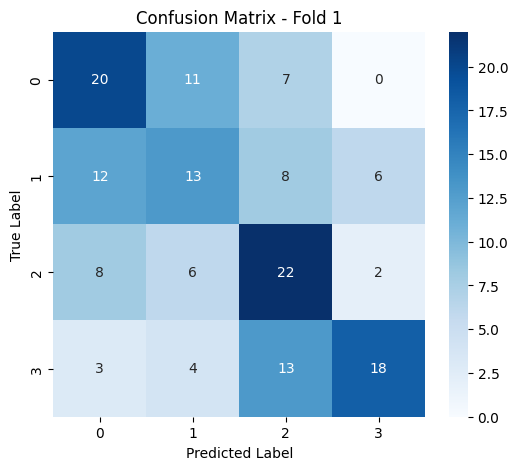


Classification Report - Fold 1:
              precision    recall  f1-score   support

           0       0.47      0.53      0.49        38
           1       0.38      0.33      0.36        39
           2       0.44      0.58      0.50        38
           3       0.69      0.47      0.56        38

    accuracy                           0.48       153
   macro avg       0.49      0.48      0.48       153
weighted avg       0.49      0.48      0.48       153


--- Fold 2/5 ---
Fold 2 Accuracy: 0.3333


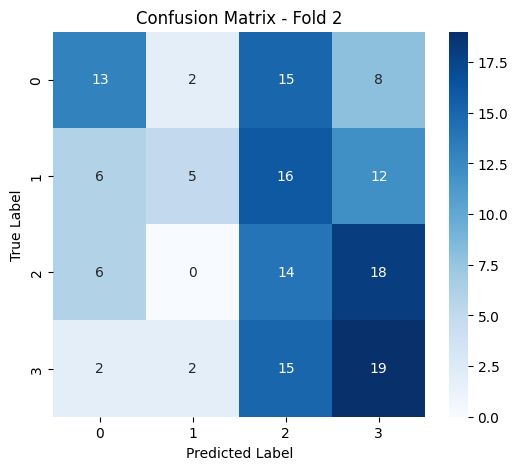


Classification Report - Fold 2:
              precision    recall  f1-score   support

           0       0.48      0.34      0.40        38
           1       0.56      0.13      0.21        39
           2       0.23      0.37      0.29        38
           3       0.33      0.50      0.40        38

    accuracy                           0.33       153
   macro avg       0.40      0.33      0.32       153
weighted avg       0.40      0.33      0.32       153


--- Fold 3/5 ---
Fold 3 Accuracy: 0.3660


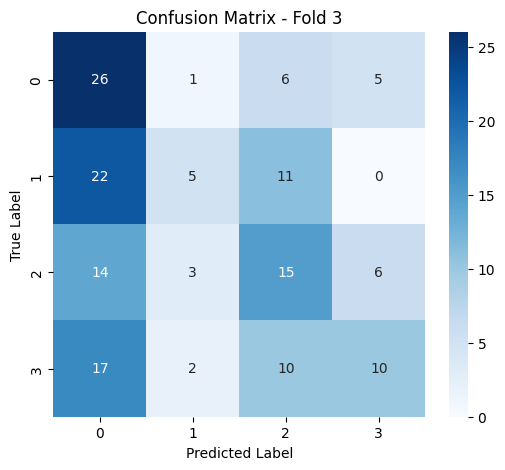


Classification Report - Fold 3:
              precision    recall  f1-score   support

           0       0.33      0.68      0.44        38
           1       0.45      0.13      0.20        38
           2       0.36      0.39      0.38        38
           3       0.48      0.26      0.33        39

    accuracy                           0.37       153
   macro avg       0.40      0.37      0.34       153
weighted avg       0.40      0.37      0.34       153


--- Fold 4/5 ---
Fold 4 Accuracy: 0.3464


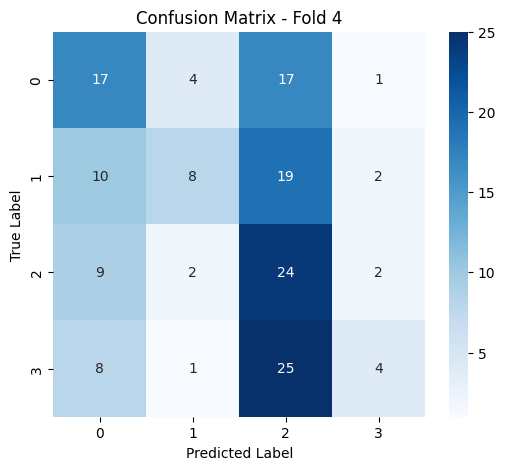


Classification Report - Fold 4:
              precision    recall  f1-score   support

           0       0.39      0.44      0.41        39
           1       0.53      0.21      0.30        39
           2       0.28      0.65      0.39        37
           3       0.44      0.11      0.17        38

    accuracy                           0.35       153
   macro avg       0.41      0.35      0.32       153
weighted avg       0.41      0.35      0.32       153


--- Fold 5/5 ---
Fold 5 Accuracy: 0.5066


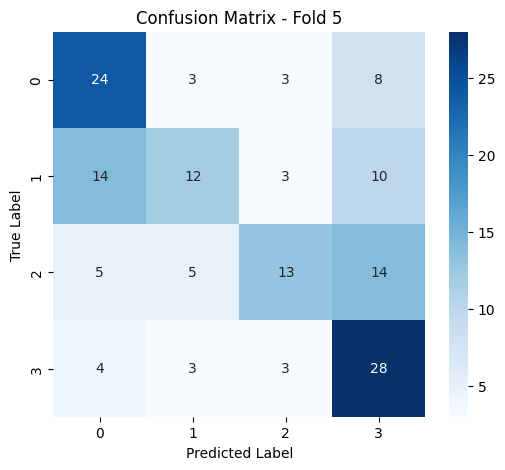


Classification Report - Fold 5:
              precision    recall  f1-score   support

           0       0.51      0.63      0.56        38
           1       0.52      0.31      0.39        39
           2       0.59      0.35      0.44        37
           3       0.47      0.74      0.57        38

    accuracy                           0.51       152
   macro avg       0.52      0.51      0.49       152
weighted avg       0.52      0.51      0.49       152


--- K-Fold برای Whole کامل شد ---

--- دقت کلی K-Fold (روی کل داده‌ها): 0.4058 ---
کل پیش‌بینی‌های درست: 310
کل پیش‌بینی‌ها: 764

تعداد کل پیش‌بینی‌های درست (در همه فولد‌ها) برای هر کلاس:
0    100
1     43
2     88
3     79
Name: count, dtype: int64

تعداد کل پیش‌بینی‌های اشتباه (در همه فولد‌ها) برای هر کلاس:
0     91
1    151
2    100
3    112
Name: count, dtype: int64

تعداد نمونه‌هایی که همیشه درست پیش‌بینی شده‌اند (در همه فولد‌هایی که ظاهر شده‌اند): 310
تعداد نمونه‌هایی که همیشه اشتباه پیش‌بینی شده‌اند (در همه فولد‌هایی ک

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



# تعداد فولدها
N_FOLDS = 5

# ایجاد K-Fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# ایجاد ستون برای ذخیره خطاها و پیش‌بینی‌ها
df_hard = df_filtered.copy()
df_hard['hardness_score'] = 0.0  # مجموع عدم اطمینان نسبت به کلاس واقعی برای هر نمونه
df_hard['fold_predictions'] = [None] * len(df_hard)  # پیش‌بینی‌های کلاس هر فولد
df_hard['fold_true'] = [None] * len(df_hard)        # مقدار واقعی کلاس هر فولد
df_hard['fold_probabilities'] = [None] * len(df_hard) # تمام احتمالات پیش‌بینی شده هر فولد
df_hard['fold_correct'] = [False] * len(df_hard)    # آیا در فولد مربوطه درست پیش‌بینی شده

# تابع پیش‌پردازش
def preprocess_image_with_class(image_path, class_label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image, class_label

def make_classification_dataset(image_paths, class_labels, batch_size=16, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, class_labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(image_paths))
    ds = ds.map(preprocess_image_with_class, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# حلقه K-Fold
for fold, (train_idx, test_idx) in enumerate(skf.split(df_hard['image_path'], df_hard['class'])):
    print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")

    # جدا کردن داده‌های فولد
    train_paths_fold = df_hard.iloc[train_idx]['image_path'].values
    train_labels_fold = df_hard.iloc[train_idx]['class'].values.astype('int32')

    test_paths_fold = df_hard.iloc[test_idx]['image_path'].values
    test_labels_fold = df_hard.iloc[test_idx]['class'].values.astype('int32')

    # ساخت مجموعه داده
    train_ds_fold = make_classification_dataset(train_paths_fold, train_labels_fold, batch_size=16)
    test_ds_fold = make_classification_dataset(test_paths_fold, test_labels_fold, batch_size=16, shuffle=False)

    # تعریف مدل (4 کلاس)
    num_classes = 4
    base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model_fold = Model(inputs, outputs)
    model_fold.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # آموزش مدل
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model_fold.fit(
        train_ds_fold,
        epochs=50,
        validation_data=test_ds_fold,
        callbacks=[early_stopping],
        verbose=0
    )

    # پیش‌بینی روی داده‌های تست فولد فعلی
    predictions_fold = model_fold.predict(test_ds_fold, verbose=0)
    predicted_classes_fold = np.argmax(predictions_fold, axis=1)

    # محاسبه دقت فولد
    true_classes_fold = test_labels_fold
    fold_accuracy = accuracy_score(true_classes_fold, predicted_classes_fold)
    print(f"Fold {fold+1} Accuracy: {fold_accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(true_classes_fold, predicted_classes_fold)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title(f'Confusion Matrix - Fold {fold+1}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print(f"\nClassification Report - Fold {fold+1}:")
    print(classification_report(true_classes_fold, predicted_classes_fold))

    # محاسبه عدم اطمینان نسبت به کلاس واقعی
    # احتمال مدل برای کلاس واقعی نمونه
    true_class_probs = predictions_fold[np.arange(len(true_classes_fold)), true_classes_fold]
    # عدم اطمینان = 1 - احتمال کلاس واقعی
    uncertainty_scores = 1 - true_class_probs

    # ذخیره خطاها، پیش‌بینی‌ها و احتمالات در دیتافریم
    df_hard.loc[test_idx, 'hardness_score'] += uncertainty_scores
    for i, idx in enumerate(test_idx):
        if df_hard.at[idx, 'fold_predictions'] is None:
            df_hard.at[idx, 'fold_predictions'] = []
            df_hard.at[idx, 'fold_true'] = []
            df_hard.at[idx, 'fold_probabilities'] = []
        df_hard.at[idx, 'fold_predictions'].append(int(predicted_classes_fold[i]))
        df_hard.at[idx, 'fold_true'].append(int(true_classes_fold[i]))
        df_hard.at[idx, 'fold_probabilities'].append(predictions_fold[i].tolist()) # ذخیره تمام احتمالات

    # محاسبه آیا درست یا اشتباه بوده (بر اساس پیش‌بینی کلاس)
    correct_mask = (predicted_classes_fold == true_classes_fold)
    df_hard.loc[test_idx, 'fold_correct'] = correct_mask

    # حذف مدل برای آزادسازی حافظه
    del model_fold
    tf.keras.backend.clear_session()

# --- محاسبه avg_hardness ---

df_hard['prediction_count'] = df_hard['fold_predictions'].apply(len)
df_hard['avg_hardness'] = df_hard['hardness_score'] / df_hard['prediction_count']

# مرتب‌سازی بر اساس avg_hardness
df_sorted_by_hardness = df_hard.sort_values(by='avg_hardness', ascending=False).reset_index(drop=True)

print("\n--- K-Fold برای Whole کامل شد ---")


total_correct_predictions = df_sorted_by_hardness['fold_correct'].apply(lambda x: sum(x) if isinstance(x, list) else int(x)).sum()

total_predictions_made = df_sorted_by_hardness['fold_predictions'].apply(len).sum()

overall_accuracy = total_correct_predictions / total_predictions_made
print(f"\n--- دقت کلی K-Fold (روی کل داده‌ها): {overall_accuracy:.4f} ---")
print(f"کل پیش‌بینی‌های درست: {total_correct_predictions}")
print(f"کل پیش‌بینی‌ها: {total_predictions_made}")

all_correct_classes = []
all_incorrect_classes = []
for idx, row in df_sorted_by_hardness.iterrows():
    if isinstance(row['fold_predictions'], list) and isinstance(row['fold_true'], list):
        for pred, true in zip(row['fold_predictions'], row['fold_true']):
            if pred == true:
                all_correct_classes.append(row['class']) # کلاس واقعی نمونه
            else:
                all_incorrect_classes.append(row['class'])

all_correct_classes_series = pd.Series(all_correct_classes)
class_distribution_all_correct = all_correct_classes_series.value_counts().sort_index()

all_incorrect_classes_series = pd.Series(all_incorrect_classes)
class_distribution_all_incorrect = all_incorrect_classes_series.value_counts().sort_index()

print(f"\nتعداد کل پیش‌بینی‌های درست (در همه فولد‌ها) برای هر کلاس:")
print(class_distribution_all_correct)

print(f"\nتعداد کل پیش‌بینی‌های اشتباه (در همه فولد‌ها) برای هر کلاس:")
print(class_distribution_all_incorrect)

always_correct_mask = df_sorted_by_hardness.apply(lambda row: all(p == t for p, t in zip(row['fold_predictions'], row['fold_true'])), axis=1)
always_correct_df = df_sorted_by_hardness[always_correct_mask]

print(f"\nتعداد نمونه‌هایی که همیشه درست پیش‌بینی شده‌اند (در همه فولد‌هایی که ظاهر شده‌اند): {len(always_correct_df)}")


always_wrong_mask = df_sorted_by_hardness.apply(lambda row: all(p != t for p, t in zip(row['fold_predictions'], row['fold_true'])), axis=1)
always_wrong_df = df_sorted_by_hardness[always_wrong_mask]

print(f"تعداد نمونه‌هایی که همیشه اشتباه پیش‌بینی شده‌اند (در همه فولد‌هایی که ظاهر شده‌اند): {len(always_wrong_df)}")


print("\nچند نمونه از داده‌هایی که همیشه درست پیش‌بینی شده‌اند:")
print(always_correct_df[['file_name', 'class', 'fpf', 'avg_hardness']].head(10))

print("\nچند نمونه از داده‌هایی که همیشه اشتباه پیش‌بینی شده‌اند:")
print(always_wrong_df[['file_name', 'class', 'fpf', 'avg_hardness']].head(10))


final_sorted_df_with_predictions = df_sorted_by_hardness
save_path = '/content/drive/MyDrive/FPF_PROJECT/Whole/final_sorted_df_with_predictions_probabilities_and_hardness_v3.csv'
final_sorted_df_with_predictions.to_csv(save_path, index=False)
print(f"\nداده‌های نهایی (با پیش‌بینی‌ها، احتمالات و سختی) در مسیر زیر ذخیره شد:\n{save_path}")

In [ ]:
import pandas as pd

# --- 1. بارگذاری داده ---
file_path = '/content/drive/MyDrive/FPF_PROJECT/final_sorted_df_with_predictions_probabilities_and_hardness_v3.csv'
df_sorted = pd.read_csv(file_path)

print(f"تعداد کل داده‌ها: {len(df_sorted)}")


df_sorted = df_sorted.sort_values(by='avg_hardness', ascending=True).reset_index(drop=True)


classes = df_sorted['class'].unique()
easy_test_parts = []

for class_idx in classes:
    df_class = df_sorted[df_sorted['class'] == class_idx].reset_index(drop=True)
    n_total_class = len(df_class)
    n_selected_class = int(n_total_class * 0.20)


    selected_part = df_class.iloc[:n_selected_class]
    easy_test_parts.append(selected_part)

    print(f"کلاس {class_idx}: تعداد کل = {n_total_class}, 20% = {n_selected_class}, انتخاب شده = {len(selected_part)}")

# --- 4. ادغام قسمت‌های انتخابی ---
easy_test_set = pd.concat(easy_test_parts, ignore_index=True)


easy_test_set = easy_test_set.sample(frac=1, random_state=42).reset_index(drop=True)

# --- 6. بررسی کلی ---
n_total_overall = len(df_sorted)
n_selected_overall = len(easy_test_set)
percentage_overall = (n_selected_overall / n_total_overall) * 100

print(f"\n--- خلاصه ---")
print(f"تعداد کل داده‌های اصلی: {n_total_overall}")
print(f"تعداد داده‌های انتخابی برای تست آسان: {n_selected_overall}")
print(f"درصد داده‌های انتخابی نسبت به کل: {percentage_overall:.2f}%")

print(f"\nتوزیع کلاس در مجموعه تست آسان:")
print(easy_test_set['class'].value_counts().sort_index())

# --- 7. ذخیره مجموعه تست آسان ---
save_path = '/content/drive/MyDrive/FPF_PROJECT/easy_test_set_20_percent.csv'
easy_test_set.to_csv(save_path, index=False)
print(f"\nمجموعه تست آسان در مسیر زیر ذخیره شد:\n{save_path}")

تعداد کل داده‌ها: 764
کلاس 0: تعداد کل = 191, 20% = 38, انتخاب شده = 38
کلاس 3: تعداد کل = 191, 20% = 38, انتخاب شده = 38
کلاس 2: تعداد کل = 188, 20% = 37, انتخاب شده = 37
کلاس 1: تعداد کل = 194, 20% = 38, انتخاب شده = 38

--- خلاصه ---
تعداد کل داده‌های اصلی: 764
تعداد داده‌های انتخابی برای تست آسان: 151
درصد داده‌های انتخابی نسبت به کل: 19.76%

توزیع کلاس در مجموعه تست آسان:
class
0    38
1    38
2    37
3    38
Name: count, dtype: int64

مجموعه تست آسان در مسیر زیر ذخیره شد:
/content/drive/MyDrive/FPF_PROJECT/easy_test_set_20_percent.csv


تعداد کل نمونه‌های تست آسان: 151

--- آمارهای توصیفی avg_hardness برای هر کلاس در تست آسان ---
       count      mean       std       min       25%       50%       75%  \
class                                                                      
0       38.0  0.237223  0.110771  0.012110  0.145332  0.252750  0.331042   
1       38.0  0.453580  0.151925  0.086539  0.344122  0.484584  0.593095   
2       37.0  0.385820  0.151019  0.056896  0.269994  0.415013  0.505056   
3       38.0  0.336396  0.137899  0.038323  0.269585  0.364619  0.452574   

            max  
class            
0      0.395931  
1      0.626666  
2      0.559501  
3      0.504598  


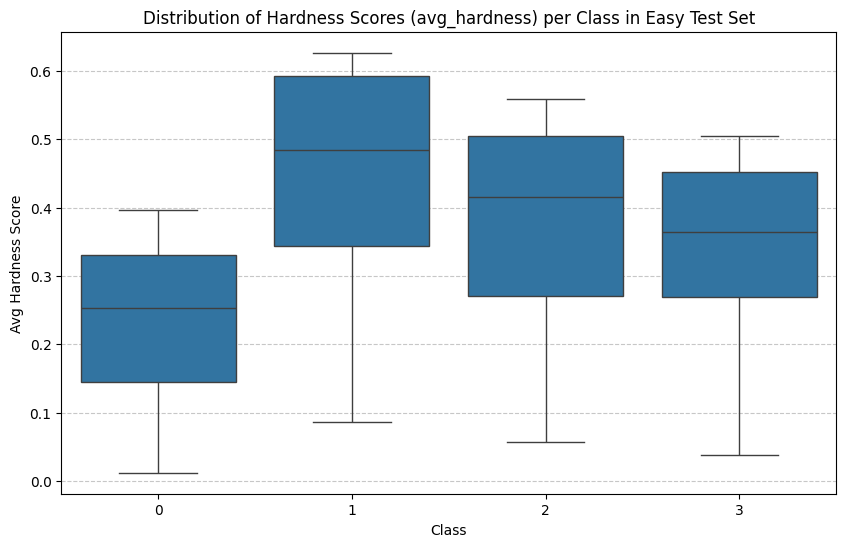


--- تعداد نمونه‌ها در هر کلاس از تست آسان ---
class
0    38
1    38
2    37
3    38
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


easy_test_path = '/content/drive/MyDrive/FPF_PROJECT/easy_test_set_20_percent.csv'
easy_test_set = pd.read_csv(easy_test_path)

print(f"تعداد کل نمونه‌های تست آسان: {len(easy_test_set)}")


hardness_stats_by_class = easy_test_set.groupby('class')['avg_hardness'].describe()

print("\n--- آمارهای توصیفی avg_hardness برای هر کلاس در تست آسان ---")
print(hardness_stats_by_class)


plt.figure(figsize=(10, 6))
sns.boxplot(data=easy_test_set, x='class', y='avg_hardness')
plt.title('Distribution of Hardness Scores (avg_hardness) per Class in Easy Test Set')
plt.xlabel('Class')
plt.ylabel('Avg Hardness Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


class_counts = easy_test_set['class'].value_counts().sort_index()
print("\n--- تعداد نمونه‌ها در هر کلاس از تست آسان ---")
print(class_counts)

In [ ]:
import pandas as pd

#  بارگذاری داده‌های اصلی
file_path_main = '/content/drive/MyDrive/FPF_PROJECT/final_sorted_df_with_predictions_probabilities_and_hardness_v3.csv'
df_sorted = pd.read_csv(file_path_main)

#  بارگذاری مجموعه تس
easy_test_path = '/content/drive/MyDrive/FPF_PROJECT/easy_test_set_20_percent.csv'
easy_test_set = pd.read_csv(easy_test_path)
test_indices = set(easy_test_set.index)

# ایجاد train_set با حذف این اندیس‌ها
train_set = df_sorted.drop(index=test_indices).reset_index(drop=True)

print(f"تعداد داده‌های کل: {len(df_sorted)}")
print(f"تعداد داده‌های تست آسان: {len(easy_test_set)}")
print(f"تعداد داده‌های آموزش: {len(train_set)}")

print("train_set و easy_test_set بارگذاری و ایجاد شدند.")

تعداد داده‌های کل: 764
تعداد داده‌های تست آسان: 151
تعداد داده‌های آموزش: 613
train_set و easy_test_set بارگذاری و ایجاد شدند.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. تعریف مدل
print("1. تعریف مدل طبقه‌بندی برای Whole (4 کلاس) با 20 لایه آخر DenseNet قابل آموزش...")

num_classes = 4

base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# قفل کردن لایه‌های پایه
base_model.trainable = False

# فاین تیون آخرین 20 لایه
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[fine_tune_at:]:
  layer.trainable = True

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=True) # training=True چون لایه‌هایی مثل BatchNorm یا Dropout فعال هستند
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model_finetuned_partially_whole = Model(inputs, outputs)

# کامپایل با lr کم
model_finetuned_partially_whole.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # lr کم برای fine-tune
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_finetuned_partially_whole.summary()

# 2. ساخت مجموعه داده
print("\n2. ساخت مجموعه داده...")

def preprocess_image_with_class(image_path, class_label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image, class_label

def make_classification_dataset(image_paths, class_labels, batch_size=16, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, class_labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(image_paths))
    ds = ds.map(preprocess_image_with_class, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# تهیه مسیرها و کلاس‌ها از train_set و test_set
train_paths = train_set['image_path'].values
train_labels = train_set['class'].values.astype('int32')

test_paths = easy_test_set['image_path'].values
test_labels = easy_test_set['class'].values.astype('int32')

train_ds = make_classification_dataset(train_paths, train_labels, batch_size=16)
test_ds = make_classification_dataset(test_paths, test_labels, batch_size=16, shuffle=False)

print(f"تعداد نمونه‌های آموزش: {len(train_paths)}")
print(f"تعداد نمونه‌های تست: {len(test_paths)}")

# --- 3. آموزش مدل ---
print("\n3. آموزش مدل (Fine-tune آخرین 20 لایه شبیه Particle)...")

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1)

history = model_finetuned_partially_whole.fit(
    train_ds,
    epochs=100,
    validation_data=test_ds,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- 4. ارزیابی مدل ---
print("\n4. ارزیابی مدل...")

# ارزیابی Accuracy
test_loss, test_accuracy = model_finetuned_partially_whole.evaluate(test_ds, verbose=0)
train_loss, train_accuracy = model_finetuned_partially_whole.evaluate(train_ds, verbose=0)
print(f"Final Train Loss: {train_loss:.4f}")
print(f"Final Train Accuracy: {train_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")

# --- 5. ذخیره مدل ---
model_save_path = '/content/drive/MyDrive/FPF_PROJECT/trained_classifier_model_whole_partial_finetune.h5'
model_finetuned_partially_whole.save(model_save_path)
print(f"\nمدل طبقه‌بندی (فاین تیون جزئی) در مسیر زیر ذخیره شد:\n{model_save_path}")



1. تعریف مدل طبقه‌بندی برای Whole (4 کلاس) با 20 لایه آخر DenseNet قابل آموزش...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,668,100 (52.14 MB)

 Trainable params: 1,560,068 (5.95 MB)

 Non-trainable params: 12,108,032 (46.19 MB)


2. ساخت مجموعه داده...
تعداد نمونه‌های آموزش: 613
تعداد نمونه‌های تست: 151

3. آموزش مدل (Fine-tune آخرین 20 لایه شبیه Particle)...
Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.2806 - loss: 1.4664 - val_accuracy: 0.3709 - val_loss: 1.3176 - learning_rate: 1.0000e-04
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 267ms/step - accuracy: 0.3461 - loss: 1.3438 - val_accuracy: 0.5695 - val_loss: 1.2040 - learning_rate: 1.0000e-04
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 246ms/step - accuracy: 0.4350 - loss: 1.2623 - val_accuracy: 0.6689 - val_loss: 1.0771 - learning_rate: 1.0000e-04
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - accuracy: 0.4450 - loss: 1.2377 - val_accuracy: 0.7219 - val_loss: 0.9209 - learning_rate: 1.0000e-04
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 225ms/step - accuracy: 0.5137 - loss: 1.1503 - val_accuracy: 0.8146 - val_loss: 0.7493 - learning_rate: 1.0000e-04
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/step - accuracy: 0.5559 - loss: 

Final Train Loss: 0.0001
Final Train Accuracy: 1.0000
Final Test Loss: 0.0000
Final Test Accuracy: 1.0000

مدل طبقه‌بندی (فاین تیون جزئی) در مسیر زیر ذخیره شد:
/content/drive/MyDrive/FPF_PROJECT/trained_classifier_model_whole_partial_finetune.h5


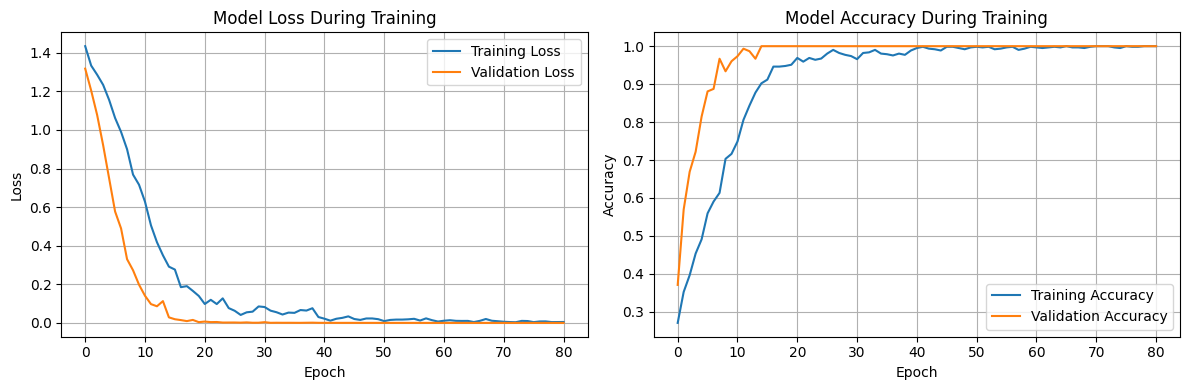

In [ ]:
import matplotlib.pyplot as plt

# 1. نمودار Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. نمودار Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy During Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.linear_model import LinearRegression
import pickle

# --- 1. بارگذاری متادیتا ---
excel_path = "/content/drive/MyDrive/FPF_PROJECT/dataset_whole.xlsx"
df_whole_meta = pd.read_excel(excel_path, sheet_name="Sheet1")
print("داده‌های متادیتا Whole بارگذاری شد.")
print(df_whole_meta.head())

# --- 2. استخراج نام فایل از ستون path ---
df_whole_meta['extracted_file_name'] = df_whole_meta['path'].apply(lambda x: x.split('/')[-1]) # فرض بر این است که جداکننده / است

# --- 3. تقسیم fpf به 4 کلاس (همانند قبل) ---
df_whole_meta['class'] = pd.qcut(df_whole_meta['fpf'], q=4, labels=False, duplicates='drop')

print("\nتعداد نمونه در هر کلاس:")
print(df_whole_meta['class'].value_counts().sort_index())

print("\nبازه‌های fpf برای هر کلاس:")
print(df_whole_meta.groupby('class')['fpf'].agg(['min', 'max']))

داده‌های متادیتا Whole بارگذاری شد.
   idx       file_name  scalebar_px  scalebar_mi  mi_per_px  crop_w_px  \
0    2  TH04_F1_01.png      137.866          5.0   0.036267        476   
1    2  TH04_F1_02.png      139.620          5.0   0.035811        491   
2    4     TH04_F2.png       92.950          5.0   0.053792        472   
3    5     TH04_F3.png      105.508          5.0   0.047390        465   
4    6     TH04_F4.png      145.870          5.0   0.034277        465   

   crop_h_px     res   fpf                          path  
0        523  248948  48.3  ./Whole/SIN_TH04_F1_01_W.png  
1        531  260721  48.3  ./Whole/SIN_TH04_F1_02_W.png  
2        520  245440  46.1     ./Whole/SIN_TH04_F2_W.png  
3        522  242730  41.1     ./Whole/SIN_TH04_F3_W.png  
4        523  243195  43.5     ./Whole/SIN_TH04_F4_W.png  

تعداد نمونه در هر کلاس:
class
0    191
1    194
2    188
3    191
Name: count, dtype: int64

بازه‌های fpf برای هر کلاس:
        min    max
class             
0     

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model, load_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

# --- 1. بارگذاری مدل طبقه‌بندی آموزش‌دیده `Whole` ---
model_load_path = '/content/drive/MyDrive/FPF_PROJECT/trained_classifier_model_whole_partial_finetune.h5'

model_finetuned_full_whole = tf.keras.models.load_model(model_load_path)

print(f"مدل طبقه‌بندی Whole با موفقیت از مسیر زیر بارگذاری شد:\n{model_load_path}")

# --- 2. استخراج ویژگر ---
try:
    feature_extractor = Model(inputs=model_finetuned_full_whole.input, outputs=model_finetuned_full_whole.get_layer('global_average_pooling2d').output)
except ValueError:
    try:
        feature_extractor = Model(inputs=model_finetuned_full_whole.input, outputs=model_finetuned_full_whole.get_layer('global_average_pooling2d_1').output)
    except ValueError:
        feature_extractor = Model(inputs=model_finetuned_full_whole.input, outputs=model_finetuned_full_whole.get_layer('global_average_pooling2d_2').output)

print("فیچر اکسترکتور ایجاد شد.")

def preprocess_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def extract_features(image_paths, batch_size=16):
    n = len(image_paths)
    features_list = []
    for i in range(0, n, batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_images = [preprocess_image(path) for path in batch_paths]
        batch_images = tf.stack(batch_images)
        batch_features = feature_extractor.predict(batch_images, verbose=0)
        features_list.append(batch_features)
    return np.vstack(features_list)

# --- 3. جدا کردن داده‌های هر کلاس برای رگرسیون ---
regression_models = {}
regression_results = {}

num_classes = 4 # برای Whole

for class_idx in range(num_classes):
    print(f"\n--- کلاس {class_idx} ---")

    # فیلتر داده‌های مربوط به این کلاس از train_set
    class_train_data = train_set[train_set['class'] == class_idx].copy()

    if len(class_train_data) == 0:
        print(f"هیچ نمونه‌ای برای کلاس {class_idx} در train_set وجود ندارد.")
        continue

    class_img_paths = class_train_data['image_path'].values
    class_fpf_values = class_train_data['fpf'].values

    print(f"تعداد نمونه‌های کلاس {class_idx}: {len(class_img_paths)}")
    print(f"بازه fpf: [{class_fpf_values.min():.2f}, {class_fpf_values.max():.2f}]")

    # استخراج ویژگی
    print("استخراج ویژگی...")
    X_features = extract_features(class_img_paths)
    y_target = class_fpf_values

    # --- آموزش مدل رگرسیون ---
    regressor = RandomForestRegressor(n_estimators=100, random_state=42)
    regressor.fit(X_features, y_target)

    # ذخیره مدل رگرسیون
    regression_models[class_idx] = regressor

    # --- ارزیابی مدل رگرسیون ---
    class_test_data = easy_test_set[easy_test_set['class'] == class_idx].copy()
    if len(class_test_data) > 0:
        test_img_paths = class_test_data['image_path'].values
        test_fpf_values = class_test_data['fpf'].values
        X_test_features = extract_features(test_img_paths)
        y_pred = regressor.predict(X_test_features)

        mae = mean_absolute_error(test_fpf_values, y_pred)
        mse = mean_squared_error(test_fpf_values, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(test_fpf_values, y_pred)

        regression_results[class_idx] = {
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'N_test_samples': len(test_fpf_values)
        }

        print(f"ارزیابی روی {len(test_fpf_values)} نمونه تست:")
        print(f"  MAE: {mae:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  R²: {r2:.4f}")
    else:
        print(f"هیچ نمونه تستی برای کلاس {class_idx} وجود ندارد.")

# --- 4. ذخیره مدل‌های رگرسیون ---
for class_idx, model in regression_models.items():
    model_path = f'/content/drive/MyDrive/FPF_PROJECT/regressor_class_{class_idx}_whole.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"مدل رگرسیون کلاس {class_idx} (Whole) در {model_path} ذخیره شد.")

print("\n--- پایپلاین دو مرحله‌ای رگرسیون برای Whole کامل شد ---")

# --- 5. چاپ خلاصه نتایج ---
print("\n--- خلاصه نتایج ارزیابی رگرسیون روی تست آسان Whole ---")
for class_idx in range(num_classes):
    if class_idx in regression_results:
        res = regression_results[class_idx]
        print(f"کلاس {class_idx} (N={res['N_test_samples']}): MAE={res['MAE']:.4f}, RMSE={res['RMSE']:.4f}, R2={res['R2']:.4f}")
    else:
        print(f"کلاس {class_idx}: نتیجه‌ای برای ارزیابی وجود ندارد.")

مدل طبقه‌بندی Whole با موفقیت از مسیر زیر بارگذاری شد:
/content/drive/MyDrive/FPF_PROJECT/trained_classifier_model_whole_partial_finetune.h5
فیچر اکسترکتور ایجاد شد.

--- کلاس 0 ---
تعداد نمونه‌های کلاس 0: 169
بازه fpf: [0.00, 24.80]
استخراج ویژگی...
ارزیابی روی 38 نمونه تست:
  MAE: 2.0906
  RMSE: 2.4295
  R²: 0.9190

--- کلاس 1 ---
تعداد نمونه‌های کلاس 1: 130
بازه fpf: [24.90, 41.00]
استخراج ویژگی...
ارزیابی روی 38 نمونه تست:
  MAE: 1.4330
  RMSE: 1.7105
  R²: 0.8669

--- کلاس 2 ---
تعداد نمونه‌های کلاس 2: 160
بازه fpf: [41.10, 60.40]
استخراج ویژگی...
ارزیابی روی 37 نمونه تست:
  MAE: 1.8073
  RMSE: 2.1581
  R²: 0.8673

--- کلاس 3 ---
تعداد نمونه‌های کلاس 3: 154
بازه fpf: [60.80, 95.81]
استخراج ویژگی...
ارزیابی روی 38 نمونه تست:
  MAE: 2.0566
  RMSE: 2.5803
  R²: 0.8741
مدل رگرسیون کلاس 0 (Whole) در /content/drive/MyDrive/FPF_PROJECT/regressor_class_0_whole.pkl ذخیره شد.
مدل رگرسیون کلاس 1 (Whole) در /content/drive/MyDrive/FPF_PROJECT/regressor_class_1_whole.pkl ذخیره شد.
مدل رگرسیون ک